In [2]:
%pip install catppuccin

In [3]:
import tensorflow as tf
import catppuccin
import keras
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.style.use(["dark_background", catppuccin.PALETTE.mocha.identifier])

In [4]:
path_to_file = keras.utils.get_file('shakespeare.txt', 'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt')
text = open(path_to_file, 'rb').read().decode(encoding='utf-8')[:100000]
len(text)


1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


100000

In [5]:
docs = text.lower().split('\n')
docs = [doc for doc in docs if len(doc.split(' '))> 5]
len(docs), docs[:10]

(1741,
 ['before we proceed any further, hear me speak.',
  'you are all resolved rather to die than to famish?',
  'first, you know caius marcius is chief enemy to the people.',
  "let us kill him, and we'll have corn at our own price.",
  "no more talking on't; let it be done: away, away!",
  'we are accounted poor citizens, the patricians good.',
  'what authority surfeits on would relieve us: if they',
  'would yield us but the superfluity, while it were',
  'wholesome, we might guess they relieved us humanely;',
  'but they think we are too dear: the leanness that'])

In [6]:
tokenizer = tf.keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(docs)
len(tokenizer.index_word)

2835

In [7]:
tokenizer.texts_to_sequences([docs[0]])[0]

[130, 23, 339, 178, 167, 94, 28, 85]

In [8]:
def n_gram_builder(corpus, tokenizer):
    input_sequences = []

    for doc in corpus:
        tokens = tokenizer.texts_to_sequences([doc])[0]
        for i in range(1, len(tokens)):
            input_sequences.append(tokens[:i+1])

    return input_sequences

encoded_data = n_gram_builder(docs, tokenizer)
encoded_data[:10]

[[130, 23],
 [130, 23, 339],
 [130, 23, 339, 178],
 [130, 23, 339, 178, 167],
 [130, 23, 339, 178, 167, 94],
 [130, 23, 339, 178, 167, 94, 28],
 [130, 23, 339, 178, 167, 94, 28, 85],
 [4, 26],
 [4, 26, 39],
 [4, 26, 39, 691]]

In [9]:
MAX_LEN = len(max(encoded_data, key=lambda x: len(x)))
MAX_LEN

13

In [10]:
from keras.utils import pad_sequences

def pad_data(data, max_len):
    padded_data = np.array(pad_sequences(data, maxlen=max_len, padding='pre'))
    return padded_data

padded_data = pad_data(encoded_data, MAX_LEN)
padded_data[:10]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 130,  23],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 130,  23, 339],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 130,  23, 339, 178],
       [  0,   0,   0,   0,   0,   0,   0,   0, 130,  23, 339, 178, 167],
       [  0,   0,   0,   0,   0,   0,   0, 130,  23, 339, 178, 167,  94],
       [  0,   0,   0,   0,   0,   0, 130,  23, 339, 178, 167,  94,  28],
       [  0,   0,   0,   0,   0, 130,  23, 339, 178, 167,  94,  28,  85],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   4,  26],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   4,  26,  39],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,  26,  39, 691]],
      dtype=int32)

In [11]:
TOTAL_WORDS = len(tokenizer.word_index) + 1

X =  np.array([doc[:-1] for doc in padded_data])
y =  np.array([doc[-1] for doc in padded_data])

X.shape, y.shape

((12807, 12), (12807,))

In [12]:
from keras.layers import Input, Embedding, Bidirectional, GRU, Dense, Dropout

model = keras.Sequential([
    Input(shape=(MAX_LEN-1,)),
    Embedding(input_dim=TOTAL_WORDS, output_dim=128),
    Bidirectional(GRU(150, return_sequences=True)),
    Bidirectional(GRU(150)),
    Dropout(0.35),
    Dense(TOTAL_WORDS, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 12, 128)        │       363,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 12, 300)        │       252,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 300)            │       406,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2836)           │       853,636 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,875,444 (7.15 MB)

 Trainable params: 1,875,444 (7.15 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from keras.callbacks import EarlyStopping
EPOCHS = 50

early_stopping = EarlyStopping(
    monitor="loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(X, y, epochs=EPOCHS, callbacks=[early_stopping])

Epoch 1/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 67s 128ms/step - accuracy: 0.0443 - loss: 6.6148
Epoch 2/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 81s 125ms/step - accuracy: 0.0588 - loss: 6.1818
Epoch 3/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 50s 126ms/step - accuracy: 0.0750 - loss: 5.9147
Epoch 4/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 82s 126ms/step - accuracy: 0.0898 - loss: 5.6266
Epoch 5/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 49s 123ms/step - accuracy: 0.1106 - loss: 5.2932
Epoch 6/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 50s 125ms/step - accuracy: 0.1245 - loss: 4.9418
Epoch 7/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 50s 124ms/step - accuracy: 0.1479 - loss: 4.5748
Epoch 8/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 50s 125ms/step - accuracy: 0.1858 - loss: 4.1776
Epoch 9/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 82s 125ms/step - accuracy: 0.2334 - loss: 3.7829
Epoch 10/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 50s 124ms/step - accuracy: 0.2947 - loss: 3.3970
Epoch 11/50
401/401 ━━━━━━━━━━━━━━━━━━━━ 51s 126ms/step - accuracy: 0.3543 - loss: 3.0412
Epoch 12/50
401/401

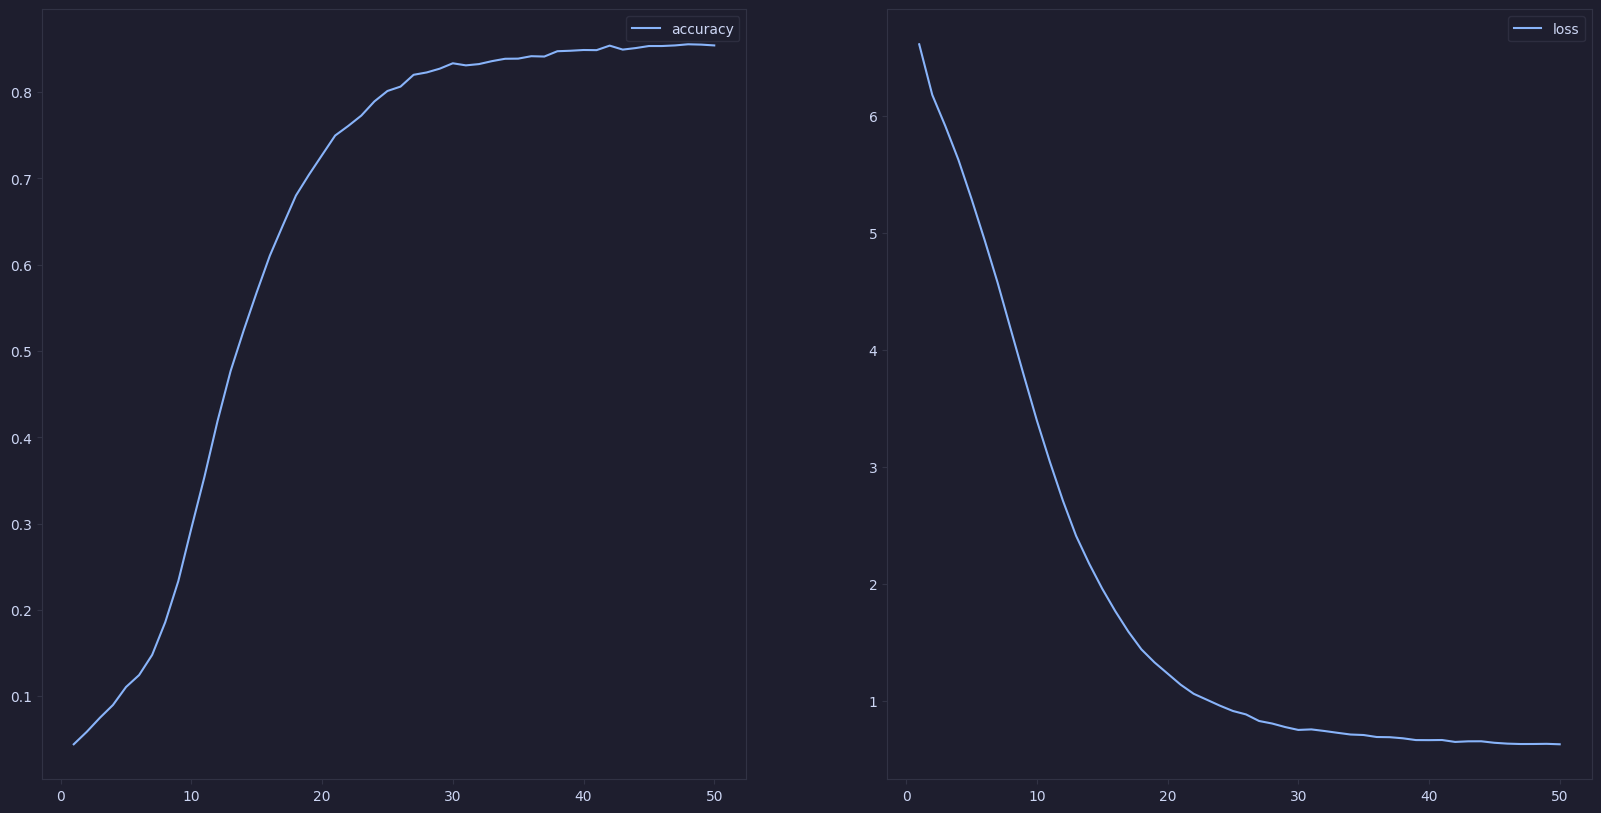

In [14]:
import numpy as np
x = np.array(history.epoch) + np.array([1])

plt.figure(figsize=(20,10))
for i, metric in enumerate(['accuracy', 'loss']):
    graph = history.history[metric]
    ax = plt.subplot(1,2, i+1)
    ax.plot(x, graph, label=metric)
    ax.legend()
plt.show()

In [15]:
def generate_sequence(text, sequence_length=10):

    for _ in range(sequence_length):
        tokens = tokenizer.texts_to_sequences([text])[0]
        padded_text =  pad_sequences([tokens], maxlen=MAX_LEN-1, padding='pre')
        predicted = model.predict(padded_text, verbose=0)
        predicted_arg = np.argmax(predicted, axis=-1)
        next_word = tokenizer.index_word[predicted_arg[0]]
        text += f" {next_word}"
    return text

res = generate_sequence("contracted to thine own bright eyes", 100)
res

"contracted to thine own bright eyes of the nobility and giddy censure for such heads butts me up do millions in the business madam how he shall flatter them in a mile confound they leads a taste of his voice feats put them them to do it to be so proud i' the dust and tinder like to peace that and do in corioli so he is covetous and in his wounds and tell us his vengeance home and should do do't to them i will be heard it that be so looks and not not law less against the rich against the rich and provide"